# Setup

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [3]:
import os
import json
import shutil
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from data_handlers.data_loading.dataset_registry import build_dataset, get_dataset_config_path
from utils.file_management import serialize_config, get_version_folder
from utils.plots import show_images
from utils.augmentation import GeometricAug, NoiseAug
from model import EncoderDecoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


# Generic Config
Same keys for every dataset — these are experiment choices, not dataset properties.
`dataset_config['num_classes']` gets filled in below, by whichever dataset is selected.

In [4]:
dataset_config = {
    'batch_size': 32,
    'dataset_seed': 1,
    'labeled_fraction': 0.01,
    'input_size': (256, 256),
}
# 'num_classes' and 'in_channels' are NOT set here — they're dataset properties, not
# experiment choices, so build_dataset() returns them and they get filled in below
# (see the "Generic data loaders" cell). in_channels is 1 for the grayscale
# ultrasound datasets and 3 for RGB CelebAMask-HQ.

# ============================================================
# DATASET SELECTION
 All dataset-specific values (paths, channels, sites, ...) live in that
 dataset's own JSON config under data_loading/<Dataset>/dataset_config.json
 — see dataset_registry.py. Switching datasets is just changing the name
 below (once the target dataset has a build_dataset() registered).
# ============================================================

In [5]:
DATASET_NAME = 'chaos_ct'

## Run selection
Resolved *before* the loaders are built (not in "Training Run Config" below), because
building the loaders needs to already know whether this is a fresh run or a resume —
see the dataset-config snapshot note below.

In [6]:
# Set to a run number (e.g. 37) to resume that run, or None to start fresh
LOAD_RUN = None

# Separate run root per dataset, so runs from different datasets never collide or
# share a version counter (get_version_folder's index.txt is per-root).
root = os.path.join('cache/model_weights/semisup', DATASET_NAME)

if LOAD_RUN is not None:
    index_folder = os.path.join(root, str(LOAD_RUN))
    print(f'Resuming run {LOAD_RUN} at {index_folder}')
else:
    index_folder = get_version_folder(root)
    print(f'Starting a new run at {index_folder}')

# Dataset-config snapshot: a fresh run copies the CURRENT
# data_handlers/data_loading/<Dataset>/dataset_config.json into this run's folder AND
# records the semi-supervised split knobs (labeled_fraction, dataset_seed) next to it,
# so the run folder is fully self-describing and later edits to the live file OR to the
# dataset_config cell above never retroactively change what an already-started run
# means. Resuming loads that saved snapshot back — the dataset config via
# build_dataset()'s dataset_config_path kwarg below, and labeled_fraction/dataset_seed
# restored into `dataset_config` here — so LOAD_RUN reproduces the exact dataset
# scenario (including how much supervision) the run originally started with.
run_dataset_config_path = os.path.join(index_folder, 'dataset_config.json')
if LOAD_RUN is not None:
    with open(run_dataset_config_path) as f:
        _snap = json.load(f)
    for _k in ('labeled_fraction', 'dataset_seed'):
        if _k in _snap:
            dataset_config[_k] = _snap[_k]
    print(f'Using this run\'s saved dataset config: {run_dataset_config_path}')
    print(f'  restored labeled_fraction={dataset_config["labeled_fraction"]}, '
          f'dataset_seed={dataset_config["dataset_seed"]}')
else:
    shutil.copyfile(get_dataset_config_path(DATASET_NAME), run_dataset_config_path)
    with open(run_dataset_config_path) as f:
        _snap = json.load(f)
    _snap['labeled_fraction'] = dataset_config['labeled_fraction']
    _snap['dataset_seed'] = dataset_config['dataset_seed']
    with open(run_dataset_config_path, 'w') as f:
        json.dump(_snap, f, indent=2)
    print(f'Snapshotted the live dataset config + split knobs '
          f'(labeled_fraction={dataset_config["labeled_fraction"]}, '
          f'dataset_seed={dataset_config["dataset_seed"]}) to {run_dataset_config_path}')

Starting a new run at cache/model_weights/semisup/chaos_ct/13
Snapshotted the live dataset config + split knobs (labeled_fraction=0.01, dataset_seed=1) to cache/model_weights/semisup/chaos_ct/13/dataset_config.json


## Generic data loaders
Every dataset-specific concern — paths, whether/how it does a semi-supervised split,
where val comes from, DataLoader construction — lives entirely inside that dataset's
own `build_dataset()` (see `dataset_registry.py`). This notebook just asks for the
four loaders + num_classes and never special-cases any dataset by name.

In [7]:
labeled_loader, unlabeled_loader, val_loader, test_loader, num_classes, in_channels = build_dataset(
    DATASET_NAME,
    batch_size=dataset_config['batch_size'],
    labeled_fraction=dataset_config['labeled_fraction'],
    seed=dataset_config['dataset_seed'],
    dataset_config_path=run_dataset_config_path,
)
# Dataset-derived, filled in per-dataset exactly like num_classes — the notebook
# never hardcodes or special-cases either. in_channels feeds EncoderDecoder below.
dataset_config['num_classes'] = num_classes
dataset_config['in_channels'] = in_channels

val_batches = len(val_loader) if val_loader is not None else 0
print(f'num_classes: {num_classes} | in_channels: {in_channels}')
print(f'Labeled batches: {len(labeled_loader)} | Unlabeled batches: {len(unlabeled_loader)} | '
      f'Val batches: {val_batches} | Test batches: {len(test_loader)}')

SemiSupervisedDatasetWrapper: 2239 total samples (22 labeled, 2217 unlabeled)
num_classes: 2 | in_channels: 1
Labeled batches: 1 | Unlabeled batches: 70 | Val batches: 20 | Test batches: 20


## Training Run Config (generic)

In [8]:
# LOAD_RUN / root / index_folder are already resolved in the "Run selection" cell
# above (before the loaders, since building them needs to know that too) — reused
# here, not recomputed, so get_version_folder's mkdir+counter-increment only ever
# happens once per fresh run.
if LOAD_RUN is not None:
    with open(os.path.join(index_folder, 'config.json')) as f:
        train_config = json.load(f)
    print(f'Loaded config from run {LOAD_RUN}:')
else:
    train_config = {
        'lr': 1e-4,
        'epochs': 1000,
        'bottleneck_dim': 2048,
        'number_of_vectors': 4096,
        # single flag applied to ALL vectorizers (one vectorizer per class)
        'vectorizers_mat_mul': True,
        # augmentations (GeometricAug + NoiseAug)
        'geo_aug_degrees': 10,
        'geo_aug_translate': (0.1, 0.1),
        'geo_aug_scale': (0.9, 1.1),
        'geo_aug_shear': 15,
        'noise_std': 0.05,
        'brightness': 0.2,
        'contrast': 0.2,
        # loss weights
        'reconstruction_weight':100.0,
        'segmentation_weight': 1.0,
        # Which reconstruction term the training loop uses — see RECONSTRUCTION_LOSSES
        # in the losses-import cell below:
        #   'blend_then_square' : ( sum_n p_n r_n - x )^2  — the ORIGINAL. p acts as a
        #       paint-mixing ratio, so two WRONG templates whose errors cancel can score
        #       perfectly (mask becomes a shading dial), and the segmentation gradient
        #       vanishes wherever the mask has already committed.
        #   'square_then_blend' : sum_n p_n ( r_n - x )^2  — squared errors are
        #       non-negative so they CANNOT cancel; the term is linear in p, so its
        #       optimum over the simplex is a hard assignment, and the segmentation
        #       gradient becomes "how badly does template n miss this pixel".
        'reconstruction_loss': 'blend_then_square',
        # Reconstruction-loss warmup: scale the reconstruction weight from
        # reconstruction_warmup_start * reconstruction_weight (0.0 => literally 0) up
        # to the full reconstruction_weight, linearly over the first
        # reconstruction_warmup_epochs epochs, then hold flat. Applied from step 0 the
        # reconstruction term drags one vectorizer into reconstructing everything and
        # softmax(seg) collapses onto it (background stops being predicted -> Dice ~0
        # for the first few epochs). Warming it up lets the model fit per-class
        # positions from the labels first, then adapt texture. 0 epochs = off.
        # Lengthen this if the early collapse persists; see the training-loop cell.
        'reconstruction_warmup_epochs': 20,
        'reconstruction_warmup_start': 0.0,
        'eval_every_n_epochs': 1,
        'save_every_n_epochs': 5,

        # include background (channel 0) in the segmentation Dice loss, or
        # restrict Dice to foreground classes only (CE is already foreground-only)
        'dice_include_background': True,
      
        # Best-checkpoint backups — see evaluate()'s store_checkpoints flag. Separate
        # from model_path, which is just "whatever the latest epoch saved".
        'best_dice_model_path': os.path.join(index_folder, 'best_dice_model.pt'),
        'best_hd_model_path': os.path.join(index_folder, 'best_hd_model.pt'),
        'best_scores_path': os.path.join(index_folder, 'best_scores.json'),
        'config_path': os.path.join(index_folder, 'config.json'),
    }
    
    with open(train_config['config_path'], 'w') as f:
        json.dump(serialize_config(train_config), f, indent=2)
    print('Starting fresh run:')



train_config['model_path'] = os.path.join(index_folder, 'model.pt')
train_config['config_path'] = os.path.join(index_folder, 'config.json')
# Normalize the vectorizer flag (tolerate old list-form configs).
flag = train_config['vectorizers_mat_mul']
if isinstance(flag, (list, tuple)):
    flag = flag[0]
train_config['vectorizers_mat_mul'] = bool(flag)

# Backward compatibility: configs saved before these keys existed.
train_config.setdefault('dice_include_background', True)
train_config.setdefault('eval_every_n_epochs', 1)
# Warmup defaults OFF for configs saved before it existed, so resuming an older run
# reproduces its original (un-warmed) loss schedule exactly.
train_config.setdefault('reconstruction_warmup_epochs', 0)
train_config.setdefault('reconstruction_warmup_start', 0.0)
train_config.setdefault('best_dice_model_path', os.path.join(index_folder, 'best_dice_model.pt'))
train_config.setdefault('best_hd_model_path', os.path.join(index_folder, 'best_hd_model.pt'))
train_config.setdefault('best_scores_path', os.path.join(index_folder, 'best_scores.json'))

# Best-score tracking state, used by evaluate()'s store_checkpoints flag — reloaded
# from best_scores.json if this run already has one (e.g. resuming via LOAD_RUN), so
# resuming doesn't reset what counts as "best" back to nothing.
if os.path.exists(train_config['best_scores_path']):
    with open(train_config['best_scores_path']) as f:
        best_scores = json.load(f)
    print(f"Loaded existing best scores from {train_config['best_scores_path']}")
else:
    best_scores = {}
best_dice_so_far = best_scores.get('best_dice', {}).get('dice', float('-inf'))
best_hd_so_far   = best_scores.get('best_hd',   {}).get('hd',   float('inf'))

print(json.dumps(serialize_config(train_config), indent=2))

Starting fresh run:
{
  "lr": 0.0001,
  "epochs": 1000,
  "bottleneck_dim": 2048,
  "number_of_vectors": 4096,
  "vectorizers_mat_mul": true,
  "geo_aug_degrees": 10,
  "geo_aug_translate": [
    0.1,
    0.1
  ],
  "geo_aug_scale": [
    0.9,
    1.1
  ],
  "geo_aug_shear": 15,
  "noise_std": 0.05,
  "brightness": 0.2,
  "contrast": 0.2,
  "reconstruction_weight": 100.0,
  "segmentation_weight": 1.0,
  "reconstruction_loss": "blend_then_square",
  "reconstruction_warmup_epochs": 20,
  "reconstruction_warmup_start": 0.0,
  "eval_every_n_epochs": 1,
  "save_every_n_epochs": 5,
  "dice_include_background": true,
  "best_dice_model_path": "cache/model_weights/semisup/chaos_ct/13/best_dice_model.pt",
  "best_hd_model_path": "cache/model_weights/semisup/chaos_ct/13/best_hd_model.pt",
  "best_scores_path": "cache/model_weights/semisup/chaos_ct/13/best_scores.json",
  "config_path": "cache/model_weights/semisup/chaos_ct/13/config.json",
  "model_path": "cache/model_weights/semisup/chaos_ct/13

## Model (generic)

In [9]:
model = EncoderDecoder(
    bottleneck_dim=train_config['bottleneck_dim'],
    number_of_vectors=train_config['number_of_vectors'],
    vectorizers_mat_mul=[train_config['vectorizers_mat_mul']] * dataset_config['num_classes'],
    in_channels=dataset_config['in_channels'],
    input_size=dataset_config['input_size'],
).to(device)

if LOAD_RUN is not None:
    model.load_state_dict(torch.load(train_config['model_path'], map_location=device))
    print(f'Loaded state dict from {train_config["model_path"]}')

optimizer = torch.optim.Adam(model.parameters(), lr=train_config['lr'])

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

Trainable parameters: 277,545,538


## Augmentations (generic)

In [10]:
temp_path =train_config['model_path']
temp_path

'cache/model_weights/semisup/chaos_ct/13/model.pt'

In [11]:
# GeometricAug: same random transform applied to image AND label/reconstruction target
# NoiseAug:     corrupts the model input only — target stays clean
geo_aug   = GeometricAug(degrees=train_config['geo_aug_degrees'],
                         translate=train_config['geo_aug_translate'],
                         scale=train_config['geo_aug_scale'],
                         shear=train_config['geo_aug_shear'])
noise_aug = NoiseAug(noise_std=train_config['noise_std'],
                     brightness=train_config['brightness'],
                     contrast=train_config['contrast'])


def augment_samples(u_image, l_image, l_label):
    """Shared geo+noise pipeline for one (unlabeled, labeled) pair of batches.

    geo_aug runs first, with the SAME sampled transform shared between an
    image and its label. noise_aug then corrupts the model input only —
    reconstruction/segmentation targets stay clean.

    Returns: u_image_geo, u_input, l_image_geo, l_label_geo, l_input
    """
    u_image_geo              = geo_aug(u_image)
    l_image_geo, l_label_geo = geo_aug(l_image, l_label)

    u_input = noise_aug(u_image_geo)
    l_input = noise_aug(l_image_geo)

    return u_image_geo, u_input, l_image_geo, l_label_geo, l_input

## Loss Functions (generic)

In [12]:
# Losses live in utils/losses.py now (importable + unit-tested).
#   reconstruction_loss(rec, image, seg_logits)         — recombine per-vectorizer
#       reconstructions with softmax(seg) as soft masks, MSE vs the input.
#   square_then_blend_reconstruction_loss(rec, image, seg_logits)
#                                                       — same inputs, but squares each
#       per-class error BEFORE blending, so the mask can't cancel two wrong templates
#       against each other. See that function's docstring for why that matters.
#   segmentation_loss(seg_logits, labels, include_background=...)  — foreground CE + Dice.
#   dice_loss(probs, target_onehot)                     — soft multi-class Dice.
from utils.losses import (reconstruction_loss,
                          square_then_blend_reconstruction_loss,
                          segmentation_loss,
                          dice_loss)

# Pick the reconstruction term ONCE here rather than branching inside the training
# loop. Both have identical signatures and comparable magnitude, so reconstruction_weight
# and the warmup schedule stay meaningful across the switch.
RECONSTRUCTION_LOSSES = {
    'blend_then_square': reconstruction_loss,                     # original
    'square_then_blend': square_then_blend_reconstruction_loss,   # see docstring
}
# .get() with the original as default: runs saved BEFORE this knob existed have no
# 'reconstruction_loss' key in their config.json, so LOAD_RUN on run 1..11 still resumes
# and still reproduces exactly the blend-then-square behaviour it was trained with.
train_config.setdefault('reconstruction_loss', 'blend_then_square')
reconstruction_loss_fn = RECONSTRUCTION_LOSSES[train_config['reconstruction_loss']]
print(f"reconstruction term: {train_config['reconstruction_loss']}")


reconstruction term: blend_then_square


## Metrics (generic)

In [13]:
# Metrics live in utils/metrics.py now (importable + unit-tested); bodies unchanged.
#   dice_score(pred, target)                    — per-sample, per-channel Dice.
#   compute_class_dice / _iou / _hd(pred, target, num_classes)
#                                               — per-class, per-batch (mean over batch).
#   print_dice_report / print_iou_report / print_hd_report(vec, num_classes)
from utils.metrics import (dice_score, compute_class_dice, compute_class_iou,
                           compute_class_hd, print_dice_report, print_iou_report,
                           print_hd_report)

## Evaluate Function (generic)

In [14]:
# The measuring part of evaluate() now lives in utils/evaluation.py (pure: takes
# model/device/num_classes explicitly, returns (class_dice, class_iou, class_hd) and
# prints the reports). The notebook keeps only the run-orchestration wrapper around
# it: the best-checkpoint bookkeeping, which needs this run's globals.
from utils.evaluation import evaluate as _evaluate


def _update_best_checkpoints(class_dice, class_hd):
    """Compare this evaluation's mean Dice/HD (foreground classes only — same
    'foreground' mean print_dice_report/print_hd_report already show) against the best
    seen so far and, on a new best, save the model separately and update
    best_scores.json — using the class_dice/class_hd evaluate() already computed for
    its own report, so nothing gets evaluated twice.

    Model selection stays Dice/HD-based; mIoU is reported by evaluate() but not used
    here (foreground mean Dice and mean IoU rank models identically anyway).

    Mutates the globals best_dice_so_far / best_hd_so_far / best_scores set up in the
    "Training Run Config" cell.
    """
    global best_dice_so_far, best_hd_so_far, best_scores

    dice_score = class_dice[1:].mean().item()
    hd_score = class_hd[1:].mean().item() if class_hd is not None else None
    updated = False

    if dice_score > best_dice_so_far:
        best_dice_so_far = dice_score
        torch.save(model.state_dict(), train_config['best_dice_model_path'])
        best_scores['best_dice'] = {
            'dice': dice_score,
            'hd': hd_score,
            'dice_per_class': class_dice.tolist(),
            'hd_per_class': class_hd.tolist() if class_hd is not None else None,
        }
        print(f"New best Dice ({dice_score:.4f}) -> {train_config['best_dice_model_path']}")
        updated = True

    if hd_score is not None and hd_score < best_hd_so_far:
        best_hd_so_far = hd_score
        torch.save(model.state_dict(), train_config['best_hd_model_path'])
        best_scores['best_hd'] = {
            'dice': dice_score,
            'hd': hd_score,
            'dice_per_class': class_dice.tolist(),
            'hd_per_class': class_hd.tolist(),
        }
        print(f"New best HD ({hd_score:.2f}) -> {train_config['best_hd_model_path']}")
        updated = True

    if updated:
        with open(train_config['best_scores_path'], 'w') as f:
            json.dump(best_scores, f, indent=2)


def evaluate(loader, desc='Evaluating', compute_hd=True, store_checkpoints=False):
    """Notebook wrapper: run utils.evaluation.evaluate over `loader` (Dice + IoU +
    optional Hausdorff, with the per-class reports printed), then optionally feed the
    result into _update_best_checkpoints.

    store_checkpoints : val-role only — save best_dice_model.pt / best_hd_model.pt on
                        a new best, from this call's own numbers (no second pass).
                        NEVER pass True for test: test must stay untouched by any
                        model-selection decision.

    Returns: (class_dice, class_iou, class_hd) — (num_classes,) tensors; class_hd is
             None when compute_hd=False.
    """
    class_dice, class_iou, class_hd = _evaluate(
        model, loader, dataset_config['num_classes'], device,
        desc=desc, compute_hd=compute_hd,
    )
    if store_checkpoints:
        _update_best_checkpoints(class_dice, class_hd)
    return class_dice, class_iou, class_hd

## Training Loop (generic)

In [ ]:
train_losses = []
rec_losses   = []
seg_losses   = []

scaler = torch.amp.GradScaler('cuda')
torch.cuda.empty_cache()


def reconstruction_weight_for(epoch):
    """Warmed-up reconstruction weight for a given (0-indexed) epoch.

    Linear ramp: reconstruction_warmup_start * reconstruction_weight at epoch 0,
    rising to the full reconstruction_weight at epoch == reconstruction_warmup_epochs,
    flat thereafter. reconstruction_warmup_epochs == 0 disables the ramp (always full).

    NOTE: keyed off the training loop's `epoch`, which restarts at 0 on a LOAD_RUN
    resume (the loop keeps no completed-epoch count), so a resumed run re-runs the
    warmup from scratch — fine for a fresh run, worth knowing when resuming.
    """
    full = train_config['reconstruction_weight']
    w_epochs = train_config['reconstruction_warmup_epochs']
    if w_epochs <= 0:
        return full
    start = train_config['reconstruction_warmup_start']
    frac = min(1.0, epoch / w_epochs)
    return full * (start + (1.0 - start) * frac)


for epoch in range(train_config['epochs'] *10):
    model.train()
    epoch_loss = epoch_rec = epoch_seg = 0.0

    rec_weight = reconstruction_weight_for(epoch)

    labeled_batches = [b for b in labeled_loader]
    n_labeled = len(labeled_batches)

    loop = tqdm(enumerate(unlabeled_loader), total=len(unlabeled_loader),
                desc=f'Epoch {epoch+1}/{train_config["epochs"]} (rec_w={rec_weight:.2f})')

    for step, (u_image, u_label, _) in loop:
        l_image, l_label, _ = labeled_batches[step % n_labeled]

        u_image = u_image.to(device)
        l_image = l_image.to(device)
        l_label = l_label.to(device)

        u_image_geo, u_input, l_image_geo, l_label_geo, l_input = augment_samples(u_image, l_image, l_label)

        optimizer.zero_grad()

        with torch.autocast('cuda'):
            u_rec, u_seg = model(u_input)
            r_loss = reconstruction_loss_fn(u_rec, u_image_geo, u_seg)

            l_rec, l_seg = model(l_input)
            # r_loss += reconstruction_loss_fn(l_rec, l_image_geo, l_seg)
            s_loss = segmentation_loss(l_seg, l_label_geo,
                                       include_background=train_config['dice_include_background'])

            # rec_weight is the warmed-up reconstruction_weight for this epoch
            # (see reconstruction_weight_for above).
            loss =  train_config['segmentation_weight'] * s_loss + \
                    rec_weight * r_loss


        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        epoch_rec  += r_loss.item()
        epoch_seg  += s_loss.item()
        loop.set_postfix(loss=loss.item(), seg=s_loss.item(), rec=r_loss.item(),
                         rec_w=round(rec_weight, 2))
 
    n = len(unlabeled_loader)
    train_losses.append(epoch_loss / n)
    rec_losses.append(epoch_rec   / n)
    seg_losses.append(epoch_seg   / n)

    # Val only during training — test stays held out until the final evaluation cell.
    # store_checkpoints=True: this call's own Dice/HD are what maybe update
    # best_dice_model.pt / best_hd_model            .pt (see _update_best_checkpoints) — test
    # never does this, since test must stay untouched by any model-selection decision.
    if epoch % train_config['eval_every_n_epochs'] == 0:
        torch.save(model.state_dict(), train_config['model_path'])
        print('Saved to', train_config['model_path'])
    if (epoch+1) % train_config['eval_every_n_epochs'] == 0:
        if val_loader is not None:
            evaluate(val_loader, desc='Evaluating (val)', compute_hd=True, store_checkpoints=True)
        else:
            print('No val_loader for this dataset yet — skipping per-epoch evaluation '
                '(test stays held out until the final evaluation cell).')

Epoch 1/1000 (rec_w=0.00): 100%|██████████| 70/70 [00:31<00:00,  2.24it/s, loss=0.16, rec=0.0187, rec_w=0, seg=0.16]  


Saved to cache/model_weights/semisup/chaos_ct/13/model.pt


Evaluating (val): 100%|██████████| 20/20 [00:39<00:00,  1.97s/it]


Dice per class:
  Class 0 (background): 0.9916
  Class 1:                0.7838

Mean Dice (foreground 1-1): 0.7838
Mean Dice (all 2):          0.8877

IoU / Jaccard per class:
  Class 0 (background): 0.9835
  Class 1:                0.6952

Mean IoU / Jaccard (foreground 1-1): 0.6952
Mean IoU / Jaccard (all 2):          0.8394
Hausdorff distance per class (pixels):
  Class 0 (background): 11.08
  Class 1:                40.77

Mean HD (foreground 1-1): 40.77
Mean HD (all 2):          25.92


Epoch 2/1000 (rec_w=5.00): 100%|██████████| 70/70 [00:31<00:00,  2.24it/s, loss=0.18, rec=0.00914, rec_w=5, seg=0.134] 


...

Epoch 6/1000 (rec_w=25.00): 100%|██████████| 70/70 [00:32<00:00,  2.18it/s, loss=0.335, rec=0.00805, rec_w=25, seg=0.133]


Saved to cache/model_weights/semisup/chaos_ct/13/model.pt


Evaluating (val): 100%|██████████| 20/20 [00:37<00:00,  1.87s/it]


Dice per class:
  Class 0 (background): 0.9921
  Class 1:                0.8308

Mean Dice (foreground 1-1): 0.8308
Mean Dice (all 2):          0.9114

IoU / Jaccard per class:
  Class 0 (background): 0.9843
  Class 1:                0.7488

Mean IoU / Jaccard (foreground 1-1): 0.7488
Mean IoU / Jaccard (all 2):          0.8666
Hausdorff distance per class (pixels):
  Class 0 (background): 10.68
  Class 1:                28.99

Mean HD (foreground 1-1): 28.99
Mean HD (all 2):          19.83
New best Dice (0.8308) -> cache/model_weights/semisup/chaos_ct/13/best_dice_model.pt


Epoch 7/1000 (rec_w=30.00): 100%|██████████| 70/70 [00:31<00:00,  2.23it/s, loss=0.371, rec=0.00795, rec_w=30, seg=0.132]


## Debug / Scratch (generic)
Quick sanity check on one labeled batch — augment, forward, compare prediction
vs. label visually and by Dice. Self-contained (doesn't rely on training-loop
state).

train/labeled | Dice sample 0: 0.9665  | batch mean: 0.8709
test          | Dice sample 0: 0.7733  | batch mean: 0.8006


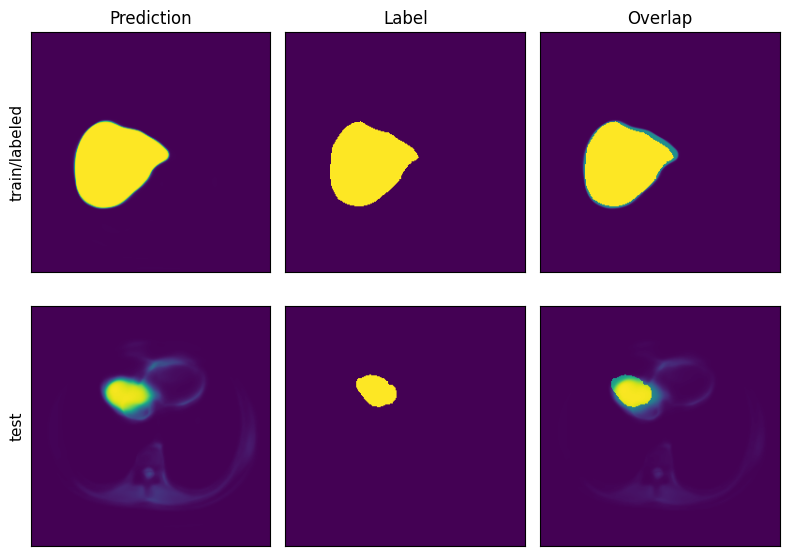

In [19]:
# Sanity check — predicted vs. ground-truth mask for one sample from the
# labeled-train set (top row) and one from the test set (bottom row).
# Raw inputs, no augmentation, so the two rows are directly comparable.
sample, channel = 0, 1


def _pred_probs(image):
    model.train()
    with torch.no_grad():
        _, seg = model(image.to(device))
    return torch.softmax(seg, dim=1).cpu()


def _row(axrow, name, label, probs):
    gt = label[sample, channel].cpu()
    pr = probs[sample, channel]
    axrow[0].imshow(pr, vmin=0, vmax=1)
    axrow[1].imshow(gt, vmin=0, vmax=1)
    axrow[2].imshow(pr + gt, vmin=0, vmax=2)
    axrow[0].set_ylabel(name, fontsize=11)
    for a in axrow:
        a.set_xticks([]); a.set_yticks([])
    print(f'{name:13s} | Dice sample {sample}: '
          f'{dice_score(label[sample], probs[sample]).mean().item():.4f}  '
          f'| batch mean: {dice_score(label, probs).mean().item():.4f}')


tr_img, tr_lab, _ = next(iter(labeled_loader))
te_img, te_lab = next(iter(val_loader))

fig, axes = plt.subplots(2, 3, figsize=(8, 6))
for c, t in enumerate(['Prediction', 'Label', 'Overlap']):
    axes[0, c].set_title(t)
_row(axes[0], 'train/labeled', tr_lab, _pred_probs(tr_img))
_row(axes[1], 'test', te_lab, _pred_probs(te_img))
plt.tight_layout()
plt.show()

## Evaluation — Dice + Hausdorff distance per class, on the held-out test set

In [ ]:
evaluate(test_loader, desc='Evaluating (test)')


Evaluating (test): 100%|██████████| 20/20 [00:38<00:00,  1.90s/it]

Dice per class:
  Class 0 (background): 0.9914
  Class 1:                0.7556

Mean Dice (foreground 1-1): 0.7556
Mean Dice (all 2):          0.8735

IoU / Jaccard per class:
  Class 0 (background): 0.9831
  Class 1:                0.6697

Mean IoU / Jaccard (foreground 1-1): 0.6697
Mean IoU / Jaccard (all 2):          0.8264
Hausdorff distance per class (pixels):
  Class 0 (background): 10.56
  Class 1:                56.18

Mean HD (foreground 1-1): 56.18
Mean HD (all 2):          33.37


(tensor([0.9914, 0.7556]),
 tensor([0.9831, 0.6697]),
 tensor([10.5563, 56.1850]))

## Visualize Predictions (generic)

/tmp/ipykernel_1109113/353712543.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


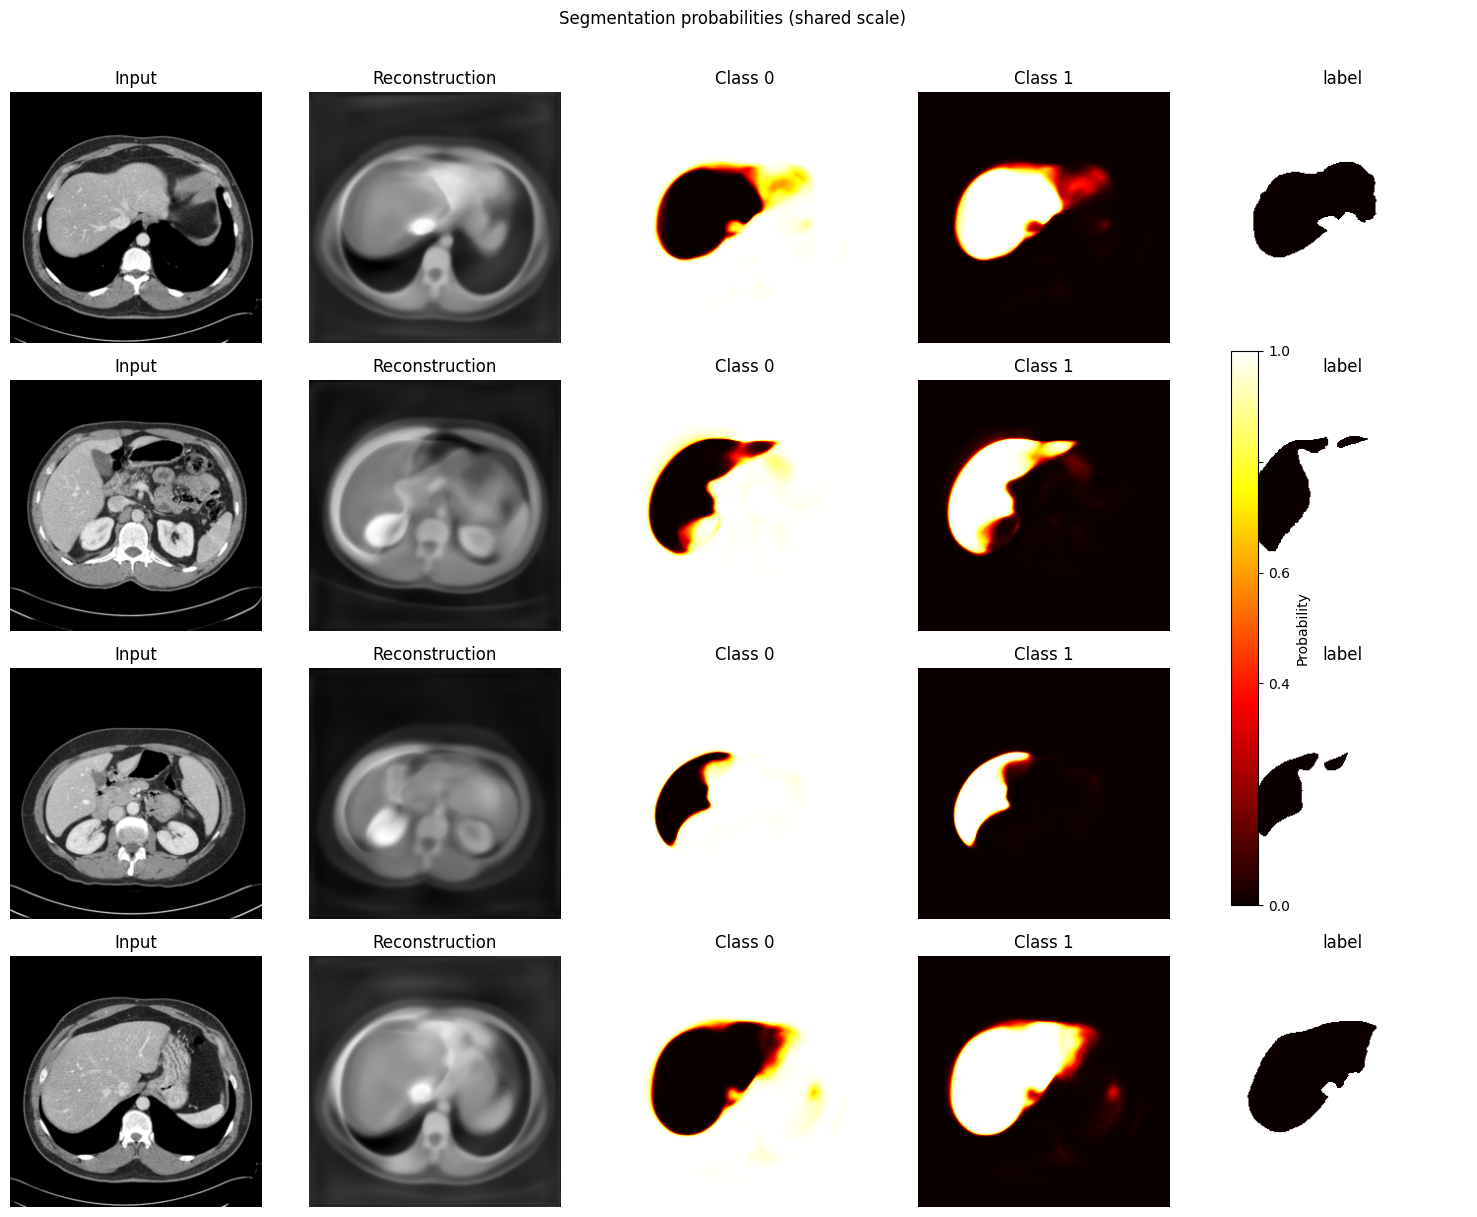

In [ ]:
model.eval()
image, label = next(iter(val_loader))
image = image.to(device)

with torch.no_grad():
    rec, seg = model(image)
    pred_probs = torch.softmax(seg, dim=1).cpu()   # (B, num_classes, H, W)


def _show_image(ax, img):
    """imshow a (C, H, W) tensor channel-agnostically: grayscale for 1 channel,
    RGB for 3 (CelebAMask-HQ)."""
    img = img.detach().cpu()
    if img.shape[0] == 1:
        ax.imshow(img[0], cmap="gray")
    else:
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1))


n_show = 4
n_cols = 3 + dataset_config['num_classes']
fig, axes = plt.subplots(n_show, n_cols, figsize=(3 * n_cols, 3 * n_show))

seg_ims = []
for i in range(n_show):
    _show_image(axes[i, 0], image[i])
    axes[i, 0].set_title("Input")
    axes[i, 0].axis("off")

    # rec[i] is (N, H, W) single-channel or (N, C, H, W) RGB — mean over vectorizers,
    # then display channel-agnostically.
    rec_i = rec[i].mean(0)
    _show_image(axes[i, 1], rec_i.unsqueeze(0) if rec_i.dim() == 2 else rec_i)
    axes[i, 1].set_title("Reconstruction")
    axes[i, 1].axis("off")

    for c in range(dataset_config['num_classes']):
        im = axes[i, 2 + c].imshow(pred_probs[i, c], cmap="hot", vmin=0, vmax=1)
        axes[i, 2 + c].set_title(f"Class {c}")
        axes[i, 2 + c].axis("off")
        seg_ims.append(im)

    im = axes[i, -1].imshow(label[i,0],  cmap="hot", vmin=0, vmax=1)
    axes[i, -1].set_title("label")
    axes[i, -1].axis("off")

# shared colorbar over all segmentation axes
seg_axes = axes[:, 2:].ravel().tolist()
fig.colorbar(seg_ims[0], ax=seg_axes, shrink=0.6, label="Probability")

plt.suptitle("Segmentation probabilities (shared scale)", y=1.01)
plt.tight_layout()
plt.show()

## Test-Time Adaptation (generic)

In [ ]:
# Test-time adaptation: fine-tune on reconstruction only, then score Dice
for loops in range(20):
    class_dice = torch.zeros(dataset_config['num_classes'])
    n_batches  = 0
    for image, label in tqdm(test_loader, desc='Evaluating loops {}'.format(loops)):
        model.load_state_dict(torch.load(train_config['model_path'], map_location=device))
        image = image.to(device)
        target = label.float().argmax(dim=1).cpu()         # (B, H, W) class indices

        model.train()
        for i in range(loops):
            optimizer.zero_grad()
            rec, seg = model(image)
            r_loss = reconstruction_loss(rec, image, seg)
            loss = r_loss
            loss.backward()
            optimizer.step()

        model.eval()
        _, seg = model(image)
        pred = seg.argmax(dim=1).cpu()                     # (B, H, W)

        class_dice += compute_class_dice(pred, target, dataset_config['num_classes'])
        n_batches += 1

    class_dice /= n_batches
    print_dice_report(class_dice, dataset_config['num_classes'])

Evaluating loops 0: 100%|██████████| 4/4 [00:02<00:00,  1.43it/s]


Dice per class:
  Class 0 (background): 0.9427
  Class 1:                0.1413
  Class 2:                0.1895

Mean Dice (foreground 1-2): 0.1654
Mean Dice (all 3):          0.4245


Evaluating loops 1: 100%|██████████| 4/4 [00:03<00:00,  1.15it/s]


Dice per class:
  Class 0 (background): 0.9531
  Class 1:                0.1415
  Class 2:                0.1937

Mean Dice (foreground 1-2): 0.1676
Mean Dice (all 3):          0.4294


Evaluating loops 2: 100%|██████████| 4/4 [00:04<00:00,  1.04s/it]


...

Dice per class:
  Class 0 (background): 0.9817
  Class 1:                0.0000
  Class 2:                0.0935

Mean Dice (foreground 1-2): 0.0468
Mean Dice (all 3):          0.3584


Evaluating loops 17: 100%|██████████| 4/4 [00:15<00:00,  3.76s/it]


Dice per class:
  Class 0 (background): 0.9825
  Class 1:                0.0000
  Class 2:                0.1190

Mean Dice (foreground 1-2): 0.0595
Mean Dice (all 3):          0.3672


Evaluating loops 18:   0%|          | 0/4 [00:03<?, ?it/s]


KeyboardInterrupt: 